# 🤖 2. Selective Preprocessing - Classification model with NO Dropouts
**Deep learning model for blue fundus eye pictures classification**

The purpose of this notebook is to evaluate the binary myopia classification model across different selective preprocessing scenarios.

The classification target is derived from the spherical equivalent value:

- `class_label = 1`: myopic eye, defined as `target_SE <= -0.50 D`
- `class_label = 0`: non-myopic eye, defined as `target_SE > -0.50 D`

The same lightweight CNN architecture is trained on four preprocessing scenarios:

A. Normalization only
- With RGB conversion and normalization to [0–1].
- No geometry: no circle detection, nor padding/resizing (only dataloader resizer for 224×224 pixels).
- No CLAHE.
- No Augmentations.

B. Geometry + Normalization
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- No Augmentations.

C. Geometry + Normalization + Illumination (no Augmentantions)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- With CLAHE (luminance or blue can be chosen).
- No Augmentations.

D. Geometry + Normalization + Augmentations (no illumination)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- With geometric Augmentations: flip, light rotation and zoom applied at dataloader.

## ⚙️ 1. Setting up



In [1]:
from pathlib import Path #useful since it makes path use easier (can append paths and more)
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    validate_main_structure,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

IMAGES_DIR = paths["images"]
TABLES_DIR = paths["tables"]
SPLITS_DIR = paths["splits"]
MODELS_DIR = paths["models"]

for folder in [IMAGES_DIR, TABLES_DIR, SPLITS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Images dir:", IMAGES_DIR)
print("Tables dir:", TABLES_DIR)
print("Splits dir:", SPLITS_DIR)
print("Models dir:", MODELS_DIR)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Images dir: C:\Users\paula\0B_TFGBiomed_Exe\Images
Tables dir: C:\Users\paula\0B_TFGBiomed_Exe\Tables
Splits dir: C:\Users\paula\0B_TFGBiomed_Exe\Splits
Models dir: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Selective preprocessing output folders ===========================================================

SPLIT_ROOT = SPLITS_DIR / "Classification" / "SelectivePreproc"
MODELS_DIR_SELECTIVE = MODELS_DIR / "WithoutDropout" / "SelectivePreproc" / "Classification"

SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR_SELECTIVE.mkdir(parents=True, exist_ok=True)

print("Split root:", SPLIT_ROOT)
print("Models selective output:", MODELS_DIR_SELECTIVE)

Split root: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\SelectivePreproc
Models selective output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithoutDropout\SelectivePreproc\Classification


In [3]:
# Paths to selectively preprocessed sets of images
SCENARIO_TABLES = {
    "A_Raw_minimal": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.A.xlsx",         # Raw with minimal preproc
    "B_GeoNorm": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx",             # geometry + normalization
    "C_GeoNorm_Illum_NoAug": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.C.xlsx", # geometry + normalization + illumination 
    "D_GeoNorm_Aug_NoIllum": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx" # geometry + normalization + augmentations - there is no such path, will be using B for D
}

EXPERIMENTS = [ # (name, data_root, augment_in_loader, normalization)
    {
        "name": "A_Raw_minimal",
        "table": SCENARIO_TABLES["A_Raw_minimal"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "B_GeoNorm",
        "table": SCENARIO_TABLES["B_GeoNorm"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "C_GeoNorm_Illum_NoAug",
        "table": SCENARIO_TABLES["C_GeoNorm_Illum_NoAug"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "D_GeoNorm_Aug_NoIllum",
        "table": SCENARIO_TABLES["D_GeoNorm_Aug_NoIllum"], #makes use of geom+norm to make augmentations without illumination
        "do_aug": True,
        "normalization": "0-1"
    }
]

for name, path in SCENARIO_TABLES.items():
    print(name, "exists:", path.exists(), "|", path)
    assert path.exists(), f"Missing scenario table: {path}"

A_Raw_minimal exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.A.xlsx
B_GeoNorm exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx
C_GeoNorm_Illum_NoAug exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.C.xlsx
D_GeoNorm_Aug_NoIllum exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx


## 🛠️  2. Helpers preparation

To keep the codebase clean and efficient, several helper functions were implemented.  
These functions encapsulate small, reusable tasks that will be required multiple times throughout the preprocessing pipeline.

####  2.1 Reading the tables

In [4]:
base_df = pd.read_excel(SCENARIO_TABLES["A_Raw_minimal"])

# Keep only rows with valid paths and classification labels
base_df = base_df[base_df["image_path"].notna()].copy()
base_df = base_df[base_df["filename"].notna()].copy()
base_df = base_df[base_df["class_label"].notna()].copy()

base_df["filename"] = base_df["filename"].astype(str)
base_df["patient_id"] = base_df["patient_id"].astype(str).str.upper().str.strip()
base_df["class_label"] = pd.to_numeric(base_df["class_label"], errors="coerce").astype("Int64")

base_df = base_df.dropna(
    subset=["image_path", "filename", "patient_id", "class_label"]
).copy()

base_df["class_label"] = base_df["class_label"].astype("int32")

print("Total valid images for classification:", len(base_df))

print("\nClassification label balance:")
print(base_df["class_label"].value_counts())

base_df.head()

Total valid images for classification: 2126

Classification label balance:
class_label
0    1645
1     481
Name: count, dtype: int64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none


#### ✂️  2.2 Splitting the dataset
Stratified (avoids bias since myope class is slightly bigger than the normal one) 80/10/10 split by chosen root dataset.

A single stratified 80/10/10 split is created from the clinical match table.

The same split is reused across all preprocessing scenarios, ensuring that the comparison between A, B, C and D is fair.

In [5]:
# Stratified 80/10/10 split based on class_label

train_base_df, tmp_base_df = train_test_split(
    base_df,
    test_size=0.2,
    stratify=base_df["class_label"],
    random_state=SEED,
    shuffle=True
)

val_base_df, test_base_df = train_test_split(
    tmp_base_df,
    test_size=0.5,
    stratify=tmp_base_df["class_label"],
    random_state=SEED,
    shuffle=True
)

print("Split sizes:")
print("Train:", len(train_base_df))
print("Validation:", len(val_base_df))
print("Test:", len(test_base_df))

print("\nTrain class balance:")
print(train_base_df["class_label"].value_counts())

print("\nValidation class balance:")
print(val_base_df["class_label"].value_counts())

print("\nTest class balance:")
print(test_base_df["class_label"].value_counts())

Split sizes:
Train: 1700
Validation: 213
Test: 213

Train class balance:
class_label
0    1315
1     385
Name: count, dtype: int64

Validation class balance:
class_label
0    165
1     48
Name: count, dtype: int64

Test class balance:
class_label
0    165
1     48
Name: count, dtype: int64


Matching each split with each preprocessing scenario:

The clinical table contains the original filename and clinical labels.

For each preprocessing scenario, the filename is matched against the corresponding preprocessed image folder. This allows the same clinical labels and same train/validation/test split to be used across all preprocessing strategies.

In [6]:
def build_filename_to_path_map(data_root: Path):
    # Creates a dictionary linking each filename to its actual path inside a preprocessing folder. Robust even if images are stored inside subfolders.
    image_paths = list(data_root.rglob("*.jpg")) + list(data_root.rglob("*.jpeg")) + list(data_root.rglob("*.png"))
    return {p.name: str(p.resolve()) for p in image_paths}

def clean_classification_table(df): # Cleans one scenario table for classification training
    df = df.copy()

    df = df[df["image_path"].notna()].copy()
    df = df[df["filename"].notna()].copy()
    df = df[df["class_label"].notna()].copy()

    df["image_path"] = df["image_path"].astype(str)
    df["filename"] = df["filename"].astype(str)
    df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
    df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("Int64")

    df = df.dropna(
        subset=["image_path", "filename", "patient_id", "class_label"]
    ).copy()

    df["class_label"] = df["class_label"].astype("int32")

    return df

def make_scenario_splits(exp): # Creates train/validation/test CSVs for one preprocessing scenario using the filenames from the base split
    name = exp["name"]
    table_path = exp["table"]

    scenario_df = pd.read_excel(table_path)
    scenario_df = clean_classification_table(scenario_df)

    train_files = set(train_base_df["filename"])
    val_files = set(val_base_df["filename"])
    test_files = set(test_base_df["filename"])

    train_s = scenario_df[scenario_df["filename"].isin(train_files)].copy()
    val_s = scenario_df[scenario_df["filename"].isin(val_files)].copy()
    test_s = scenario_df[scenario_df["filename"].isin(test_files)].copy()

    if len(train_s) != len(train_base_df):
        raise ValueError(f"{name}: train split mismatch.")
    if len(val_s) != len(val_base_df):
        raise ValueError(f"{name}: validation split mismatch.")
    if len(test_s) != len(test_base_df):
        raise ValueError(f"{name}: test split mismatch.")

    # Verify that all files exist
    for split_name, split_df in [("train", train_s), ("val", val_s), ("test", test_s)]:
        missing = split_df["image_path"].apply(lambda p: not Path(p).exists()).sum()

        if missing > 0:
            examples = split_df[split_df["image_path"].apply(lambda p: not Path(p).exists())]["image_path"].head(5).tolist()
            raise FileNotFoundError(
                f"{name} - {split_name}: {missing} paths do not exist. Examples: {examples}"
            )

    scenario_split_dir = SPLIT_ROOT / name
    scenario_split_dir.mkdir(parents=True, exist_ok=True)
    
    train_csv = scenario_split_dir / "train.csv"
    val_csv = scenario_split_dir / "val.csv"
    test_csv = scenario_split_dir / "test.csv"

    train_s.to_csv(train_csv, index=False)
    val_s.to_csv(val_csv, index=False)
    test_s.to_csv(test_csv, index=False)

    return train_csv, val_csv, test_csv


SCENARIO_SPLITS = {}

for exp in EXPERIMENTS:
    train_csv, val_csv, test_csv = make_scenario_splits(exp)

    SCENARIO_SPLITS[exp["name"]] = {
        "train": train_csv,
        "val": val_csv,
        "test": test_csv
    }

    print(f"{exp['name']}: splits saved successfully.")

A_Raw_minimal: splits saved successfully.
B_GeoNorm: splits saved successfully.
C_GeoNorm_Illum_NoAug: splits saved successfully.
D_GeoNorm_Aug_NoIllum: splits saved successfully.


#### 🧮  2.3 Decoder and normalizer
Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training. In other words, we are receiving a disk path and giving a tensor back.

Note: a tensor is the basic structure in TensorFlow (in deep learning frameworks). A picture would be a 3D tensor (hxwxchannels) and a batch of pictures would be a 4D tensor (hxwxcxbatch)

In [7]:
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], tf.float32) #mean pixels intensity on red, green, blue channels
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225], tf.float32) #standard deviations on channels

def normalize_tensor(img_float01, mode="0-1"): # Applies the selected normalization strategy
    if mode == "0-1":
        return img_float01
    if mode == "imagenet":
        return (img_float01 - IMAGENET_MEAN) / IMAGENET_STD
    if mode == "zscore":
        mean = tf.reduce_mean(img_float01, axis=[0, 1], keepdims=True)
        std = tf.math.reduce_std(img_float01, axis=[0, 1], keepdims=True) + 1e-6
        return (img_float01 - mean) / std

    return img_float01

def decode_img(path, label, normalization="0-1"): # Reads, decodes, resizes and normalizes one image
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) #decodes jpg into rgb tensor
    img = tf.image.convert_image_dtype(img, tf.float32) #converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method="bilinear") #rescales to 224x224
    img = normalize_tensor(img, mode=normalization)

    return img, tf.cast(label, tf.float32)  #gives pic+label back so dataloader knows the class it belongs to 

#### 🎭  2.4 Dataloader with(out) Lightweight augmentations
Creating the TensorFlow dataset (dataloader) with simple geometric transformations (or not) to improve generalization and reduce overfitting.

Shuffles and augmentations will only be applied if training=True

The model uses:
- three convolutional blocks,
- max pooling after the first two convolutions,
- global average pooling,
- dropout regularization,
- and a sigmoid output neuron for binary myopia classification

In [8]:
#Declare the type of augmentations to be carried out (if wanted)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])

def make_classification_ds(csv_path, training=False, normalization="0-1", do_aug=False): # Creates a TensorFlow dataset for binary myopia classification
    split_df = pd.read_csv(csv_path) #cvs path is pic+label
    paths = split_df["image_path"].astype(str).values
    labels = split_df["class_label"].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map( #applies decode_img on each image
        lambda p, y: decode_img(p, y, normalization=normalization),
        num_parallel_calls=AUTOTUNE 
    )

    if training: #if training, it shuffles (so it learns with random order) and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)

        if do_aug:
            ds = ds.map(
                lambda x, y: (augment(x, training=True), y),
                num_parallel_calls=AUTOTUNE #(aumentos)
            )

    ds = ds.batch(BATCH).prefetch(AUTOTUNE)  #prefetching makes pipeline faster; batch size declared up top

    return ds

#### 🟢  2.5 The classification model - small_cnn_classf

Definition of the small_cnn architecture used as a first baseline classifier. This was model small_cnn_classf on the Models_1FullPreproc.ipynb notebook.

In [9]:
def build_small_cnn_classf(input_shape=(224,224,3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    #x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training - NOT on this notebook
    outputs = layers.Dense(1, activation="sigmoid")(x) #binary exit (1 is the probability of myopia)
    return keras.Model(inputs, outputs)

def compile_model_classf():
    model = build_small_cnn_classf()
    model.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with lr=1e-3
                  loss="binary_crossentropy", #adecuate for binary classification with sigmoid
                  metrics=[keras.metrics.AUC(name="auc"), "accuracy"]) #AUC and accuracy metrics
    return model

In [10]:
example_model = compile_model_classf()
example_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️  2.6 Callbacks and weights
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

Class weights are correction factors used during training to handle class' number differences: errors when choosing the minority class are penalized more strongly, while errors on the majority class are penalized less. This ensures the model pays equal attention to both classes despite unequal sample counts.

In [11]:
def make_callbacks():
    return [ 
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
        keras.callbacks.ReduceLROnPlateau( monitor="val_auc", mode="max", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
    ]

def compute_weights(csv_train_path):
    train_df = pd.read_csv(csv_train_path) #Load train split
    
    classes = np.array([0,1])
    weights = compute_class_weight('balanced', classes=classes, y=train_df["class_label"].astype(int).values) #calcultes inverse weights to teh frecuency of each class
    return {0: float(weights[0]), 1: float(weights[1])} #dictionary understood by keras

#### 📦  2.7 Training and evalutation wrappers
Utility functions to make predictions on the dataset and evaluate results by stablished metrics.

In [12]:
#This function gives back true labels and predicted labels so as to calculate metrics later on
def collect_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] #true labels 1 or 0; probabilities of model 0-1
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    return y_true, y_score

#Gives back a dictionary with: model name, AUC, AP, accuracy @50% threshold, confusion matrix and classification report
def evaluate_on_test(name, model, test_ds, threshold=0.5, show_plots=True):
    y_true, y_score = collect_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    #Metric 1: ROC / PR
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    #Metric 2: Confusion matrix & report
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=["Normal","Myopia"], digits=4)

    if show_plots:
        # ROC
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        plt.plot([0,1],[0,1],'--',alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC curve – {name}")
        plt.grid(True)
        plt.legend()
        plt.show()

        # PR
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall curve – {name}")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Confusion matrix
        plt.figure(figsize=(4,3.6))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"Confusion Matrix – {name}")
        plt.xticks([0,1], ["Normal","Myopia"])
        plt.yticks([0,1], ["Normal","Myopia"])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha="center", va="center")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return {
        "name": name,
        "AUC": float(roc_auc),
        "AP": float(ap),
        "accuracy@0.5": float((y_pred == y_true).mean()),
        "confusion_matrix": cm,
        "report": report
    }

#### 🧪  2.8 Running the experiment
Full pipeline of model.

Each preprocessing scenario is trained independently using the same model architecture, same train/validation/test split, and same training configuration.

The only differences across experiments are:
- the image preprocessing level,
- and whether training-time augmentation is applied.

In [13]:
def run_experiment(exp, epochs=10):
    name = exp["name"]
    normalization = exp["normalization"]
    do_aug = exp["do_aug"]
    print(f"\n===== Running {name} =====")

    # 1) Splits (by root)
    #csv_name = ALIAS_SPLITS.get(name, name) #patch for D
    train_csv = SCENARIO_SPLITS[name]["train"]
    val_csv = SCENARIO_SPLITS[name]["val"]
    test_csv = SCENARIO_SPLITS[name]["test"]

    # In case B's CSVs didn't exist yet either - more patch for D
    #if not (os.path.exists(train_csv) and os.path.exists(val_csv) and os.path.exists(test_csv)):
    #    make_splits_for_root(data_root, out_prefix=csv_name, seed=SEED)
    
    # 2) Datasets
    train_ds = make_classification_ds(train_csv, training=True,  normalization=normalization, do_aug=do_aug)
    val_ds   = make_classification_ds(val_csv,   training=False, normalization=normalization, do_aug=False)
    test_ds  = make_classification_ds(test_csv,  training=False, normalization=normalization, do_aug=False)

    # 3) Model
    model = compile_model_classf()
    
    # 4) Class weights + callbacks
    class_weight = compute_weights(train_csv)
    print("Class weights:", class_weight)
    cb = make_callbacks()

    # 5) Train
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cb, class_weight=class_weight)

    # 6) Evaluate
    test_metrics = evaluate_on_test(name, model, test_ds, show_plots=True)
    print(test_metrics["report"])
    
    return model, history, test_metrics, (train_ds, val_ds, test_ds)


## 🚀 3. The launching of the model

Now, we'll launch the binary classification (small_cnn_classf), that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

We'll be applying it on the 4 baselines:

🇦 2.1 Small CNN with raw images - Mere normalization.

🇧 2.2 Small CNN with no Illumination and no Augmentations - This time only geometry and normalization preprocessing are applied.

🇨 2.3 Small CNN with Illumination (no augmentations) - This time only geometry, normalization and illumination preprocessing are applied.

🇩 2.4 Small CNN with Augmentations (no illumination) - This time only geometry, normalization and augmentations are applied.


===== Running A_Raw_minimal =====
Class weights: {0: 0.6463878326996197, 1: 2.207792207792208}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 515ms/step - accuracy: 0.5377 - auc: 0.4911 - loss: 0.7006 - val_accuracy: 0.3756 - val_auc: 0.6245 - val_loss: 0.6942 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 490ms/step - accuracy: 0.4059 - auc: 0.5292 - loss: 0.7047 - val_accuracy: 0.7746 - val_auc: 0.5918 - val_loss: 0.6735 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 488ms/step - accuracy: 0.7888 - auc: 0.5347 - loss: 0.6751 - val_accuracy: 0.7746 - val_auc: 0.6067 - val_loss: 0.6854 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 486ms/step - accuracy: 0.7648 - auc: 0.5591 - loss: 0.6991 - val_accuracy: 0.7793 - val_auc: 0.6240 - val_loss: 0.6826 - learning_rate: 3.0000e-04
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 491ms/step - accuracy: 0.7423 - auc: 0.5859 - loss: 0.6961 - val_accuracy: 0.7418 - val_auc: 0.6472 - val_loss: 0.6775

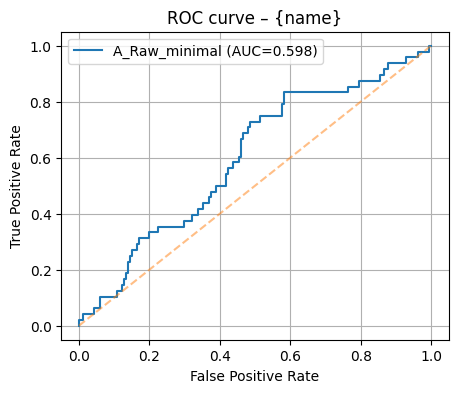

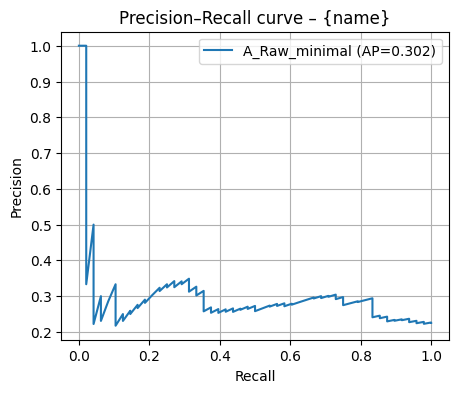

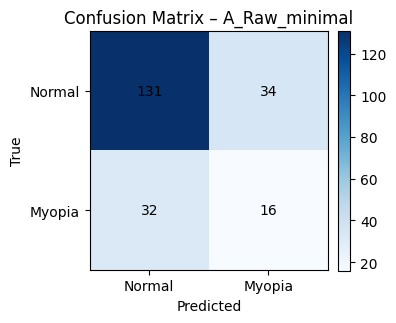

              precision    recall  f1-score   support

      Normal     0.8037    0.7939    0.7988       165
      Myopia     0.3200    0.3333    0.3265        48

    accuracy                         0.6901       213
   macro avg     0.5618    0.5636    0.5627       213
weighted avg     0.6947    0.6901    0.6924       213


===== Running B_GeoNorm =====
Class weights: {0: 0.6463878326996197, 1: 2.207792207792208}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 475ms/step - accuracy: 0.4490 - auc: 0.4710 - loss: 0.6981 - val_accuracy: 0.4178 - val_auc: 0.5393 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 472ms/step - accuracy: 0.3422 - auc: 0.4990 - loss: 0.7048 - val_accuracy: 0.7746 - val_auc: 0.5585 - val_loss: 0.6815 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 483ms/step - accuracy: 0.7751 - auc: 0.5057 - loss: 0.6762 - val_accuracy: 0.3052 - val_auc: 0.6187 - val_loss: 0.7056 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━

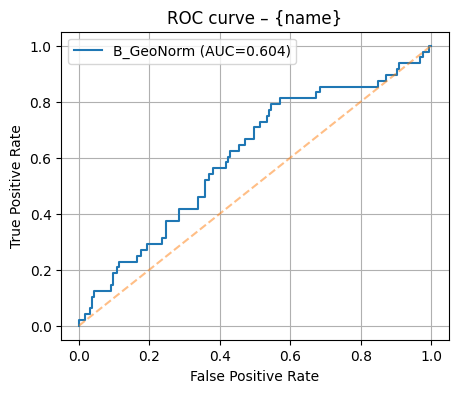

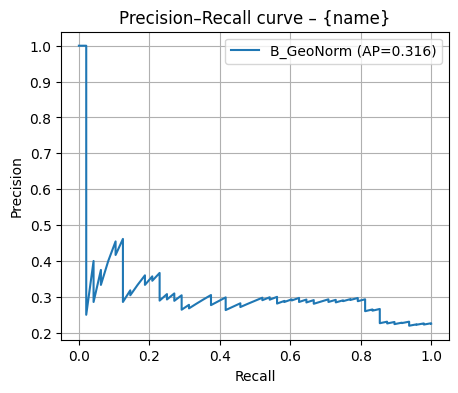

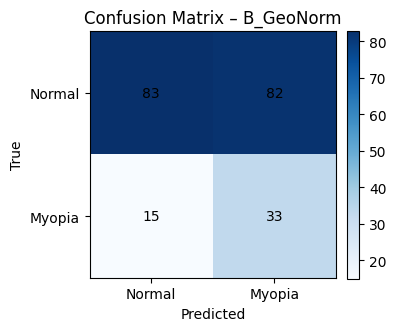

              precision    recall  f1-score   support

      Normal     0.8469    0.5030    0.6312       165
      Myopia     0.2870    0.6875    0.4049        48

    accuracy                         0.5446       213
   macro avg     0.5669    0.5953    0.5180       213
weighted avg     0.7207    0.5446    0.5802       213


===== Running C_GeoNorm_Illum_NoAug =====
Class weights: {0: 0.6463878326996197, 1: 2.207792207792208}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.5601 - auc: 0.4834 - loss: 0.7002 - val_accuracy: 0.7042 - val_auc: 0.5129 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 462ms/step - accuracy: 0.4988 - auc: 0.4898 - loss: 0.7049 - val_accuracy: 0.7746 - val_auc: 0.5584 - val_loss: 0.6792 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 462ms/step - accuracy: 0.7879 - auc: 0.5185 - loss: 0.6761 - val_accuracy: 0.6854 - val_auc: 0.5795 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 4/10
54/

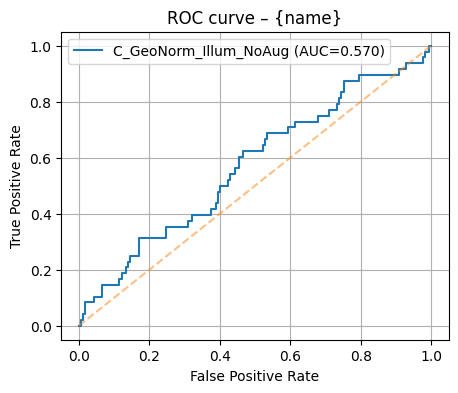

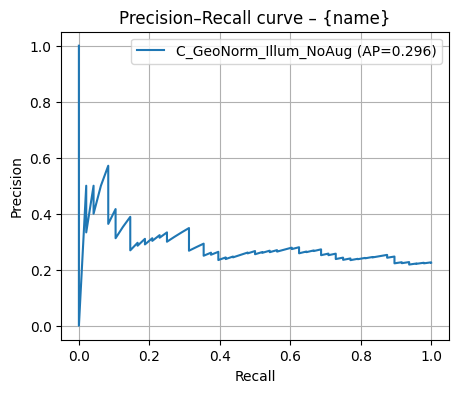

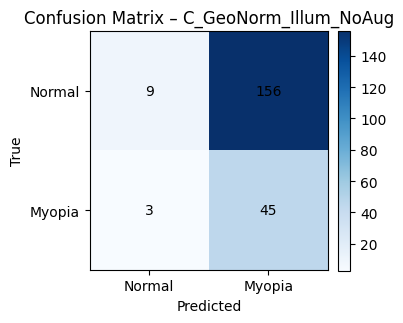

              precision    recall  f1-score   support

      Normal     0.7500    0.0545    0.1017       165
      Myopia     0.2239    0.9375    0.3614        48

    accuracy                         0.2535       213
   macro avg     0.4869    0.4960    0.2316       213
weighted avg     0.6314    0.2535    0.1602       213


===== Running D_GeoNorm_Aug_NoIllum =====
Class weights: {0: 0.6463878326996197, 1: 2.207792207792208}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 681ms/step - accuracy: 0.4905 - auc: 0.4793 - loss: 0.7005 - val_accuracy: 0.3099 - val_auc: 0.5730 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 684ms/step - accuracy: 0.3228 - auc: 0.5142 - loss: 0.7047 - val_accuracy: 0.7746 - val_auc: 0.5432 - val_loss: 0.6753 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 681ms/step - accuracy: 0.7871 - auc: 0.5162 - loss: 0.6760 - val_accuracy: 0.3756 - val_auc: 0.6217 - val_loss: 0.6957 - learning_rate: 0.0010
Epoch 4/10
54/

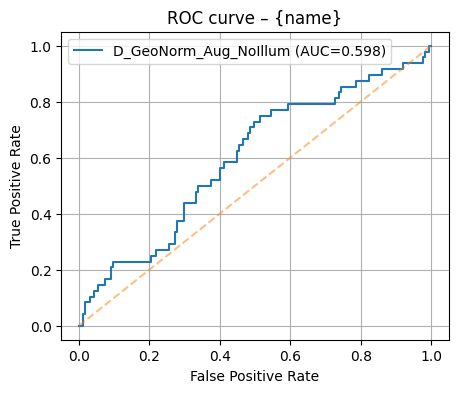

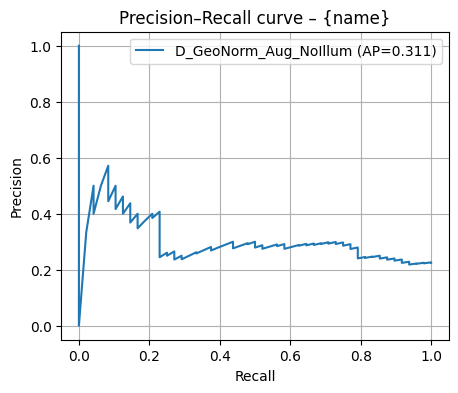

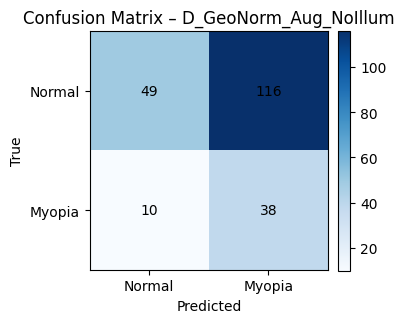

              precision    recall  f1-score   support

      Normal     0.8305    0.2970    0.4375       165
      Myopia     0.2468    0.7917    0.3762        48

    accuracy                         0.4085       213
   macro avg     0.5386    0.5443    0.4069       213
weighted avg     0.6990    0.4085    0.4237       213



,name,task,preprocessing_family,dropout,augmentation,normalization,best_val_auc,best_val_accuracy,test_auc,test_ap,test_accuracy@0.5,model_path
0,A_Raw_minimal,classification,SelectivePreproc,False,False,0-1,0.660922,0.779343,0.598359,0.301574,0.690141,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,B_GeoNorm,classification,SelectivePreproc,False,False,0-1,0.649242,0.774648,0.604419,0.315541,0.544601,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,C_GeoNorm_Illum_NoAug,classification,SelectivePreproc,False,False,0-1,0.640215,0.774648,0.570328,0.296161,0.253521,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,D_GeoNorm_Aug_NoIllum,classification,SelectivePreproc,False,True,0-1,0.649684,0.774648,0.597980,0.310605,0.408451,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


In [14]:
results = []
models  = {}
histories = {}
datasets = {}

for exp in EXPERIMENTS:
    mdl, hist, metrics, ds_tuple = run_experiment(exp, epochs=10)

    name = exp["name"]
    models[name] = mdl
    histories[name] = hist
    datasets[name] = ds_tuple

    model_path = MODELS_DIR_SELECTIVE / f"small_cnn_classification_without_dropout_{name}.keras"
    mdl.save(model_path)
    
    results.append({
        "name": name,
        "task": "classification",
        "preprocessing_family": "SelectivePreproc",
        "dropout": False,
        "augmentation": exp["do_aug"],
        "normalization": exp["normalization"],
        "best_val_auc": float(np.max(hist.history.get("val_auc", [np.nan]))),
        "best_val_accuracy": float(np.max(hist.history.get("val_accuracy", [np.nan]))),
        "test_auc": metrics["AUC"],
        "test_ap": metrics["AP"],
        "test_accuracy@0.5": metrics["accuracy@0.5"],
        "model_path": str(model_path)
    })

results_df = pd.DataFrame(results)
results_df

The results table shows a comparative of the same model (small_cnn_classf) run over the 4 different sets of preprocessed pictures:
- best_val_auc: best AUC value (capacity of model to distinguish classes) obtained accross the 10 epochs on the **validation set** (1 perfect, 0.5 random)
- best_val_acc: best accuracy value (% of right guesses) obtained accross the 10 epochs on the **validation set** (watch out for unbalanced classes in dataset)
- test_auc: AUC obtained on **test set**. This might be the most important metric
- test_ap: average precision obtained on **test set** (area under precision-recall curve). Very useful with unbalanced classes since it focuses on performance on myopia class
- test_acc@0.5: accuracy obtained on **test set** when 0.5 threshold is applied (≥ 0.5 means myopia); < 0.5 means normal)

All in all:
- AUC shows how well the model distinguishes amongst classes
- Accuracy shows % of right guesses when classifying
- AP shows how well the model handles the minority class (looking at precision vs recall)

**The best performance (by all metrics) was carried out by level XXX of preprocessing (geom + norm + illum - augms), last one being level XXX (geom + norm - illum + augms)**

Note 1: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Note 2: handling the smaller class (AP) can be complicated since, if there is a large picture number difference amongst classes, the model might learn to state it is almost always right to predict that a picture belongs to the larger group when classifying.

## 📊 4. Results

#### 📈 4.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for Keras models, making it easy to compare performance across epochs.

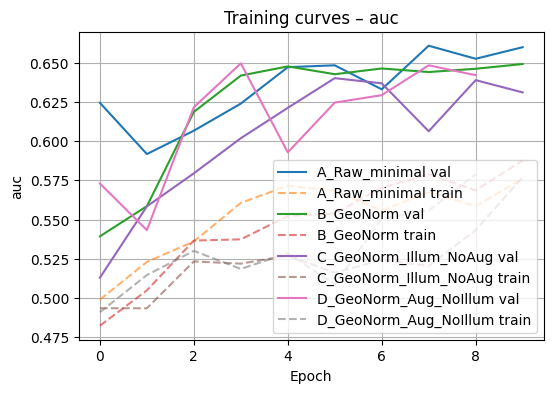

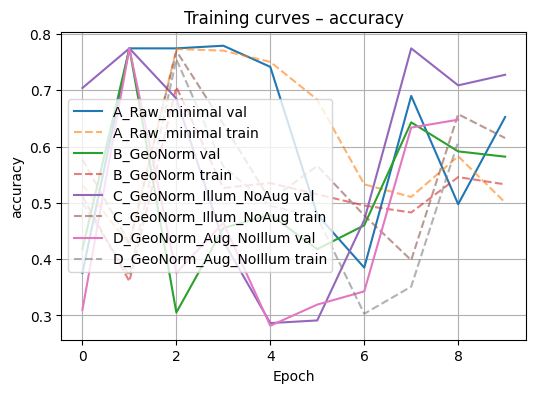

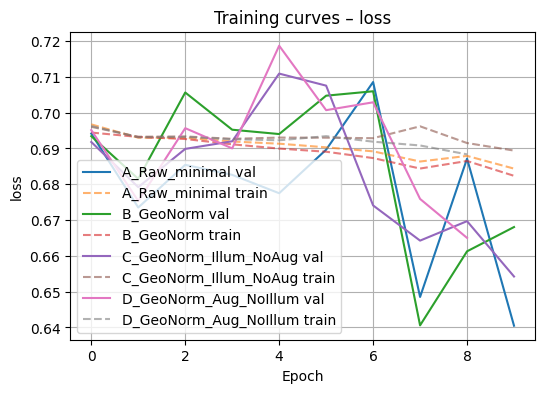

In [18]:
def plot_histories(histories_dict, metric="auc"):
    # histories_dict: dictionary of keras History objects
    # metric: "auc" | "accuracy" | "loss" | "mae" | "mse"

    plt.figure(figsize=(6, 4)) # prefer validation metric if available

    plotted_anything = False

    for name, history in histories_dict.items():
        hist = history.history

        if f"val_{metric}" in hist:
            plt.plot(hist[f"val_{metric}"], label=f"{name} val")
            plotted_anything = True

        if metric in hist:
            plt.plot(hist[metric], linestyle="--", alpha=0.6, label=f"{name} train")
            plotted_anything = True

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Training curves – {metric}")
    plt.grid(True)

    if plotted_anything:
        plt.legend()
    else:
        print(f"No history found for metric: {metric}")

    plt.show()

plot_histories(histories, metric="auc")
plot_histories(histories, metric="accuracy")
plot_histories(histories, metric="loss")

#### ⚖️ 4.2 Direct comparison A vs B vs C vs D on ROC & PR
This code evaluates multiple outcomes on the same test set, computes ROC and Precision–Recall curves (with AUC and AP), and overlays the curves to compare their performance directly.

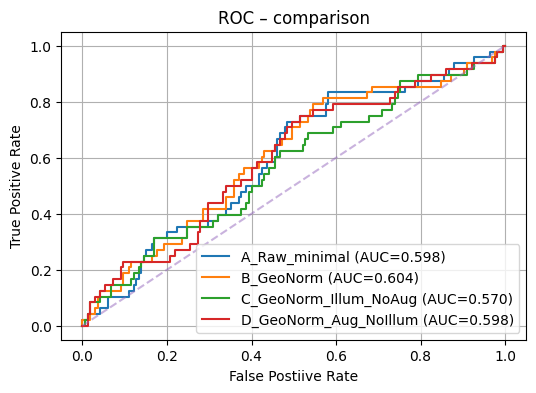

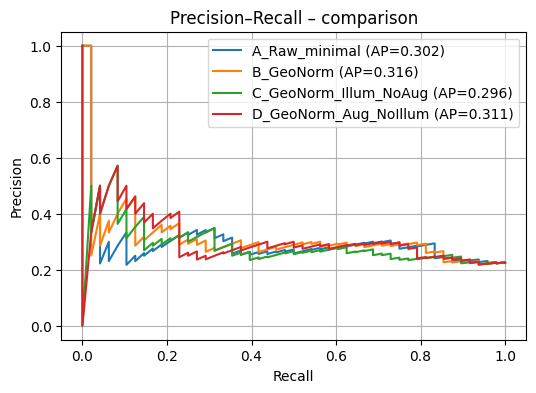

In [16]:
def compare_models_on_test(model_dict, scenario_splits, normalization="0-1"):
    
    curves = {}
    for name, mdl in model_dict.items():
        #csv_name = ALIAS_SPLITS.get(name, name)  #B for D patch
        test_csv = scenario_splits[name]["test"]  # created in run_experiment
        test_ds  = make_classification_ds(test_csv, training=False, normalization=normalization, do_aug=False)
        y_true, y_score = collect_preds(mdl, test_ds)
        fpr, tpr, _ = roc_curve(y_true, y_score)
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        ap = average_precision_score(y_true, y_score)
        curves[name] = {"fpr":fpr,"tpr":tpr,"auc":roc_auc,"precision":precision,"recall":recall,"ap":ap}

    # ROC overlay
    plt.figure(figsize=(6,4))
    for name, d in curves.items():
        plt.plot(d["fpr"], d["tpr"], label=f"{name} (AUC={d['auc']:.3f})")
    plt.plot([0,1],[0,1],'--',alpha=0.5)
    plt.xlabel("False Postiive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC – comparison")
    plt.grid(True); plt.legend(); plt.show()

    # PR overlay
    plt.figure(figsize=(6,4))
    for name, d in curves.items():
        plt.plot(d["recall"], d["precision"], label=f"{name} (AP={d['ap']:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall – comparison")
    plt.grid(True); plt.legend(); plt.show()

    return curves


classification_curves = compare_models_on_test(
    models,
    SCENARIO_SPLITS,
    normalization="0-1"
)

It is pretty clear all levels of preprocessing did well, **being slighlty better level XXX (draws more angled ROC and P-R curves).**

#### 📝 4.3 Conclusions

So as a conclusion, this **classification model (small_cnn_classf) performed pretty well across all preprocessings, obtaining slightly better results on XXXX** for:
- Distinguishing between classes on test (AUC) = XXX (val) and *XXX*(test)
- Classifying more accurately, globally (accuracy) = *XXX* (val) and *XXX* (test)
- Doing a better job at handling the smaller class (myopia) in terms of precision-recall (AP) = *XXX* (test)

On the other hand, the small_cnn_classf on the fully preprocessed model (Models_1FullPreproc notebook) gave us the following results:
- Distinguishing a bit better between classes on validation (AUC) = *XXX* (val) and XXX(test)
- Classifying less accurately, globally (accuracy) = XXX (val) and XXX (test)
- Doing a slightly worse job at handling the smaller class (myopia) in terms of precision-recall (AP) = XXX (test)

The **full preprocessed model** (small_cnn_classf on notebook 1, with the complete pipeline) achieves excellent metrics, but it **does not outperform preprocessing level XXX** (GeoNorm+Illum, no Aug), which generally delivers slightly better results on both validation and test.

Interestingly, **adding augmentations** in level XXX (GeoNorm+Aug, no Illum) actually **decreases accuracy in validation and test**.

Both level XXX (Raw minimal) and XXX (GeoNorm only) also perform remarkably well, although slightly below level XXX with this small_cnn_classf.

End :)